# Step 3: KPI Implementation & Analysis

## Identify the Best/Worst Performing Movies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/processed/movies_clean.csv")
print(df.shape)
df.head()

(18, 22)


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.239,17.5896,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,7.609,23.4619,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,7.248,8.7987,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.238,30.4635,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,7.902,21.4031,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270


### Ranking Function (UDF)

To avoid repeating the same filter-sort-head pattern for every ranking below, we define one reusable function that handles all of them.

In [3]:
def rank_movies(data, by, ascending=False, filter_column=None, min_value=None, n=10):
    if filter_column is not None:
        data = data[data[filter_column] >= min_value]
    return data.sort_values(by=by, ascending=ascending).head(n)

### Highest Revenue

In [4]:
rank_movies(df, by="revenue_musd")

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,7.609,23.4619,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.239,17.5896,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,7.902,21.4031,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,7.248,8.7987,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.238,30.4635,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733
5,135397,Jurassic World,The park is open.,2015-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,6.702,17.2889,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,7.096,13.3553,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,60
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,8.056,29.6583,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,7.219,8.6914,138,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239
13,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,7.229,13.0776,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Idina Menzel|Kristen Bell|Josh Gad|Jonathan Gr...,64,Chris Buck|Jennifer Lee,42


### Highest Budget

In [5]:
rank_movies(df, by="budget_musd")

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.239,17.5896,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.238,30.4635,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733
12,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,6.747,16.3756,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,198
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,7.096,13.3553,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,60
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,7.248,8.7987,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,7.609,23.4619,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,7.275,18.6505,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,8.056,29.6583,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640
10,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,7.364,10.8666,135,"King T'Challa returns home to the reclusive, t...",English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,7.902,21.4031,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270


### Highest Profit

Profit isn't a column TMDb provides directly — we calculate it as Revenue minus Budget.

In [6]:
# highest profit

df["profit_musd"] = df["revenue_musd"] - df["budget_musd"]
rank_movies(df, by="profit_musd")

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,23.4619,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999,2686.706026
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,17.5896,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611,2443.439100
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,21.4031,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,8.7987,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,30.4635,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733,1752.415039
5,135397,Jurassic World,The park is open.,2015-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,17.2889,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,13.3553,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,60,1402.020819
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,8.6914,138,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239,1325.400000
13,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,13.0776,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Idina Menzel|Kristen Bell|Josh Gad|Jonathan Gr...,64,Chris Buck|Jennifer Lee,42,1303.683476
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,29.6583,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515


### Lowest Profit

In [7]:
# Lowest profit
rank_movies(df, by="profit_musd", ascending=True)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd
12,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,16.3756,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,198,1034.407706
17,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,8.3896,118,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,260,1043.225667
16,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,NaN,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,11.3722,129,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,163,1106.115964
15,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,20.2458,102,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Idina Menzel|Kristen Bell|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009
14,351286,Jurassic World: Fallen Kingdom,The park is gone.,2018-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,170.0,1310.469037,Amblin Entertainment|Universal Pictures,...,7.7844,129,Three years after Jurassic World was destroyed...,English|Pусский,/x2Us3jR6ToMJjbcPbLimYoxf6xr.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,41,J. A. Bayona,393,1140.469037
10,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,10.8666,135,"King T'Challa returns home to the reclusive, t...",English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,18.6505,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694
11,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,12.7897,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,165,1216.511219
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,29.6583,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515
13,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,13.0776,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Idina Menzel|Kristen Bell|Josh Gad|Jonathan Gr...,64,Chris Buck|Jennifer Lee,42,1303.683476


### Highest ROI

ROI (Return on Investment) = Revenue / Budget. Only considering movies with Budget ≥ 10M — smaller-budget films can produce misleadingly extreme ROI numbers.

In [8]:
df["roi"] = df["revenue_musd"] / df["budget_musd"]

rank_movies(df, by="roi", filter_column="budget_musd", min_value=10)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999,2686.706026,12.336312
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812
5,135397,Jurassic World,The park is open.,2015-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583
11,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,165,1216.511219,10.732090
13,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Idina Menzel|Kristen Bell|Josh Gad|Jonathan Gr...,64,Chris Buck|Jennifer Lee,42,1303.683476,9.691223
15,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,102,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Idina Menzel|Kristen Bell|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,138,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239,1325.400000,7.975789
16,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,NaN,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,129,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,163,1106.115964,7.913225
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611,2443.439100,7.863593


### Lowest ROI

In [9]:
rank_movies(df, by="roi", ascending=True, filter_column="budget_musd", min_value=10)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
12,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,198,1034.407706,4.448026
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441
17,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,118,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,260,1043.225667,6.216128
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,60,1402.020819,6.392388
10,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,135,"King T'Challa returns home to the reclusive, t...",English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733,1752.415039,6.841383
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707
14,351286,Jurassic World: Fallen Kingdom,The park is gone.,2018-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,170.0,1310.469037,Amblin Entertainment|Universal Pictures,...,129,Three years after Jurassic World was destroyed...,English|Pусский,/x2Us3jR6ToMJjbcPbLimYoxf6xr.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,41,J. A. Bayona,393,1140.469037,7.708641
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611,2443.439100,7.863593
16,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,NaN,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,129,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,163,1106.115964,7.913225


### Most Voted Movies

In [10]:
rank_movies(df, by="vote_count")

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999,2686.706026,12.336312
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733,1752.415039,6.841383
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611,2443.439100,7.863593
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441
10,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,135,"King T'Challa returns home to the reclusive, t...",English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630
11,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,165,1216.511219,10.732090
5,135397,Jurassic World,The park is open.,2015-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729


### Highest Rated Movies

Only considering movies with at least 10 votes, since a rating based on very few votes isn't statistically meaningful.

In [11]:
rank_movies(df, by="vote_average", filter_column="vote_count", min_value=10)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611,2443.439100,7.863593
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733,1752.415039,6.841383
11,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Adventure|Fantasy,Harry Potter Collection,en,125.0,1341.511219,Heyday Films|Warner Bros. Pictures,...,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,106,David Yates,165,1216.511219,10.732090
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999,2686.706026,12.336312
17,260513,Incredibles 2,"It's been too long, dahlings.",2018-06-14,Action|Adventure|Animation|Family,The Incredibles Collection,en,200.0,1243.225667,Pixar,...,118,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,84,Brad Bird,260,1043.225667,6.216128
10,284054,Black Panther,Long live the king.,2018-02-13,Action|Adventure|Science Fiction,Black Panther Collection,en,200.0,1349.926083,Marvel Studios,...,135,"King T'Challa returns home to the reclusive, t...",English|Kiswahili|한국어/조선말,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,67,Ryan Coogler,586,1149.926083,6.749630
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441
15,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,102,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Idina Menzel|Kristen Bell|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793


### Lowest Rated Movies

In [12]:
rank_movies(df, by="vote_average", ascending=True, filter_column="vote_count", min_value=10)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
14,351286,Jurassic World: Fallen Kingdom,The park is gone.,2018-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,170.0,1310.469037,Amblin Entertainment|Universal Pictures,...,129,Three years after Jurassic World was destroyed...,English|Pусский,/x2Us3jR6ToMJjbcPbLimYoxf6xr.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,41,J. A. Bayona,393,1140.469037,7.708641
5,135397,Jurassic World,The park is open.,2015-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583
12,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,198,1034.407706,4.448026
16,321612,Beauty and the Beast,Be our guest.,2017-03-16,Family|Fantasy|Romance,NaN,en,160.0,1266.115964,Mandeville Films|Walt Disney Pictures,...,129,A live-action adaptation of Disney's version o...,English|Français,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Kevin Kline...,139,Bill Condon,163,1106.115964,7.913225
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,60,1402.020819,6.392388
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,One Race|Original Film|Universal Pictures,...,138,Deckard Shaw seeks revenge against Dominic Tor...,English|Español|العربية|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...,50,James Wan,239,1325.400000,7.975789
13,330457,Frozen II,The past is not what it seems.,2019-11-20,Adventure|Animation|Comedy|Family|Fantasy,Frozen Collection,en,150.0,1453.683476,Walt Disney Animation Studios,...,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Idina Menzel|Kristen Bell|Josh Gad|Jonathan Gr...,64,Chris Buck|Jennifer Lee,42,1303.683476,9.691223
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Action|Adventure|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Bad Robot|Lucasfilm Ltd.,...,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269,1823.223624,8.441729
15,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,102,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Idina Menzel|Kristen Bell|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441


### Most Popular Movies

In [13]:
rank_movies(df, by="popularity")

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,149,As the Avengers and their allies have continue...,English,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,733,1752.415039,6.841383
7,24428,The Avengers,Some assembly required.,2012-04-25,Action|Adventure|Science Fiction,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,143,When an unexpected enemy emerges and threatens...,English|Pусский|हिन्दी,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,640,1298.815515,6.903707
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Action|Adventure|Science Fiction,Avatar Collection,en,237.0,2923.706026,20th Century Fox|Dune Entertainment|Ingenious ...,...,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999,2686.706026,12.336312
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,20th Century Fox|Lightstorm Entertainment|Para...,...,194,101-year-old Rose DeWitt Bukater tells the sto...,Deutsch|English|Français|Italiano|Pусский|svenska,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270,2064.162353,11.320812
15,109445,Frozen,Who will save the day? The ice guy? The nice g...,2013-11-20,Adventure|Animation|Family|Fantasy,Frozen Collection,en,150.0,1274.219009,Walt Disney Animation Studios,...,102,Young princess Anna of Arendelle dreams about ...,English,/itAKcobTYGpYT8Phwjd8c9hleTo.jpg,Idina Menzel|Kristen Bell|Jonathan Groff|Josh ...,60,Chris Buck|Jennifer Lee,288,1124.219009,8.494793
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,...,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,75,Joss Whedon,660,1170.403694,5.980441
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Action|Adventure|Science Fiction,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,181,After the devastating events of Avengers: Infi...,English|日本語,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,611,2443.439100,7.863593
5,135397,Jurassic World,The park is open.,2015-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Legendary Pictures|Univer...,...,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,53,Colin Trevorrow,420,1521.537444,11.143583
12,181808,Star Wars: The Last Jedi,Let the past die.,2017-12-13,Action|Adventure|Science Fiction,Star Wars Collection,en,300.0,1334.407706,Lucasfilm Ltd.,...,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,112,Rian Johnson,198,1034.407706,4.448026
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Animation|Drama|Family,The Lion King (Reboot) Collection,en,260.0,1662.020819,Fairview Entertainment|Walt Disney Pictures,...,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,60,1402.020819,6.392388


## Advanced Movie Filtering & Search Queries

### Search 1: Best-rated Science Fiction Action movies starring Bruce Willis

Since genres and cast are stored as pipe-separated strings (not lists), we search for the actor/genre names as substrings within those strings.

In [14]:
mask = (
    df["genres"].str.contains("Science Fiction") &
    df["genres"].str.contains("Action") &
    df["cast"].str.contains("Bruce Willis")
)

search_1 = df[mask].sort_values("vote_average", ascending=False)
search_1

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi


In [15]:
print(df["cast"].str.contains("Bruce Willis").sum())
print(df["genres"].str.contains("Science Fiction").sum())
print(df["genres"].str.contains("Action").sum())

0
10
10


**Result:** No matches found. Verified this is expected, not a bug, as Bruce Willis does not appear in the cast of any of the 18 movies in this project's dataset (confirmed via `df["cast"].str.contains("Bruce Willis").sum()` returning 0), while the genre filters themselves correctly matched 10 movies each for Science Fiction and Action individually.

### Search 2: Movies starring Uma Thurman, directed by Quentin Tarantino

Sorted by runtime, shortest to longest.

In [16]:
mask = (
    df["cast"].str.contains("Uma Thurman") &
    df["director"].str.contains("Quentin Tarantino")
)

search_2 = df[mask].sort_values("runtime", ascending=True)
search_2

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit_musd,roi


In [17]:
print(df["cast"].str.contains("Uma Thurman").sum())
print(df["director"].str.contains("Quentin Tarantino").sum())

0
0


**Result:** No matches found. Verified as expected — neither Uma Thurman nor Quentin Tarantino appear anywhere in this project's dataset (both `.str.contains()` checks independently return 0), consistent with this dataset consisting entirely of major franchise blockbusters (Marvel, Star Wars, Disney, Jurassic Park, etc.) rather than Tarantino's filmography.

## Franchise vs. Standalone Movie Performance

We compare movies that belong to a franchise (`belongs_to_collection` is not null) against standalone movies, across five metrics.

In [18]:
df["franchise_status"] = df["belongs_to_collection"].notnull().map({True: "Franchise", False: "Standalone"})
print(df["franchise_status"].value_counts())

franchise_status
Franchise     16
Standalone     2
Name: count, dtype: int64


In [19]:
df.groupby("franchise_status").agg(
    mean_revenue=("revenue_musd", "mean"),
    median_roi=("roi", "median"),
    mean_budget=("budget_musd", "mean"),
    mean_popularity=("popularity", "mean"),
    mean_rating=("vote_average", "mean"),
)

,mean_revenue,median_roi,mean_budget,mean_popularity,mean_rating
franchise_status,,,,,
Franchise,1682.775216,7.786117,218.0,16.092962,7.398875
Standalone,1765.139159,9.617018,180.0,16.387650,7.434500


**Note:** This comparison is based on only 2 standalone movies versus 16 franchise movies in this dataset, so the standalone average is heavily influenced by individual outliers (e.g., Titanic). The result should not be generalized beyond this specific 18-movie sample.

## Most Successful Franchises & Directors

### Most Successful Movie Franchises

Grouping by `belongs_to_collection` (standalone movies, where this is NaN, are automatically excluded — we're only interested in actual franchises here).

In [20]:
franchise_summary = df.groupby("belongs_to_collection").agg(
    num_movies=("id", "count"),
    total_budget=("budget_musd", "sum"),
    mean_budget=("budget_musd", "mean"),
    total_revenue=("revenue_musd", "sum"),
    mean_revenue=("revenue_musd", "mean"),
    mean_rating=("vote_average", "mean"),
)

franchise_summary.sort_values("total_revenue", ascending=False)

,num_movies,total_budget,mean_budget,total_revenue,mean_revenue,mean_rating
belongs_to_collection,,,,,,
The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.9520
Star Wars Collection,2,545.0,272.50,3402.631330,1701.315665,6.9975
Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.6165
Avatar Collection,1,237.0,237.00,2923.706026,2923.706026,7.6090
Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.2390
The Lion King (Reboot) Collection,1,260.0,260.00,1662.020819,1662.020819,7.0960
The Fast and the Furious Collection,1,190.0,190.00,1515.400000,1515.400000,7.2190
Black Panther Collection,1,200.0,200.00,1349.926083,1349.926083,7.3640
Harry Potter Collection,1,125.0,125.00,1341.511219,1341.511219,8.0800


**Note:** Some franchises show only 1 movie here because this project's dataset includes just one entry from that franchise (e.g., only one Harry Potter, Avatar, or Black Panther film was fetched) — this reflects the scope of the fixed 19-ID list, not the true size of these franchises.

### Most Successful Directors

In [21]:
director_summary = df.groupby("director").agg(
    num_movies=("id", "count"),
    total_revenue=("revenue_musd", "sum"),
    mean_rating=("vote_average", "mean"),
)

director_summary.sort_values("total_revenue", ascending=False)

,num_movies,total_revenue,mean_rating
director,,,
James Cameron,2,5187.868379,7.7555
Anthony Russo|Joe Russo,2,4851.854139,8.2385
Joss Whedon,2,2924.219209,7.6655
Chris Buck|Jennifer Lee,2,2727.902485,7.2390
J.J. Abrams,1,2068.223624,7.2480
Colin Trevorrow,1,1671.537444,6.7020
Jon Favreau,1,1662.020819,7.0960
James Wan,1,1515.400000,7.2190
Ryan Coogler,1,1349.926083,7.3640


# Step 4: Data Visualization

### Revenue vs. Budget Trends

A scatter plot showing the relationship between how much a movie cost to make and how much it earned. If bigger budgets reliably produced bigger revenue, we'd expect to see points trending upward together.

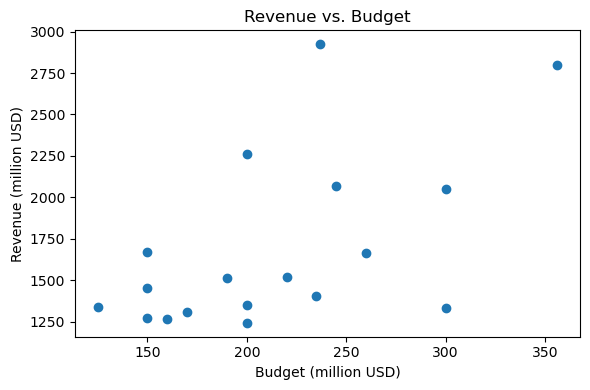

In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(df["budget_musd"], df["revenue_musd"], color="#1f77b4")
plt.xlabel("Budget (million USD)")
plt.ylabel("Revenue (million USD)")
plt.title("Revenue vs. Budget")
plt.grid(False)
plt.tight_layout()
plt.show()

**Insight:** There's a loose positive relationship between budget and revenue; higher-budget movies tend to earn more, but it's far from a strict rule. Notice Avatar (~ 237M budget) earned close to 2,900M in revenue, clearly outperforming the highest-budget movie in the set (~356M budget, ~2,800M revenue) on a per-dollar basis. This suggests budget alone doesn't guarantee proportionally higher returns, factors like franchise strength, timing, and audience appeal likely matter as much as production spend.

### ROI Distribution by Genre

Since movies can belong to multiple genres, we split the pipe-separated genre strings so each movie contributes its ROI value to every genre it belongs to (a movie tagged Action|Adventure counts in both groups).

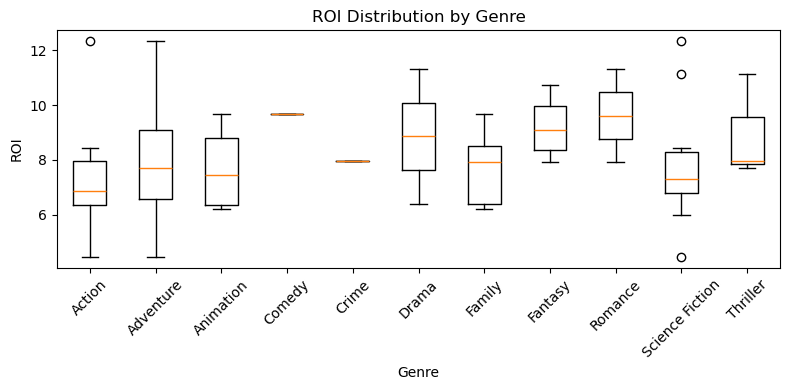

In [23]:
df_genres = df.copy()
df_genres["genre_list"] = df_genres["genres"].str.split("|")
df_genres = df_genres.explode("genre_list")

grouped = df_genres.groupby("genre_list")["roi"]
labels = list(grouped.groups.keys())
data = [grouped.get_group(g).dropna().values for g in labels]

plt.figure(figsize=(8, 4))
plt.boxplot(data, tick_labels=labels)
plt.xlabel("Genre")
plt.ylabel("ROI")
plt.title("ROI Distribution by Genre")
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

**Insight:** Action, Adventure, and Animation genres show a wide ROI spread, reflecting the mix of budget sizes across many movies. Genres like Comedy and Crime show almost no spread, this is a sample-size artifact, since this dataset includes only 1-2 movies tagged with each of those genres, not a real pattern of consistent returns. Science Fiction shows visible outliers (circles above/below the box), meaning at least one Sci-Fi movie performed unusually well or poorly relative to the rest of that group. As with the franchise comparison earlier, genre-level conclusions here should be read cautiously given the small overall dataset (18 movies split across many overlapping genre tags).

### Popularity vs. Rating

A scatter plot comparing TMDb's popularity score against average audience rating, to see whether more "popular" movies also tend to be better-rated.

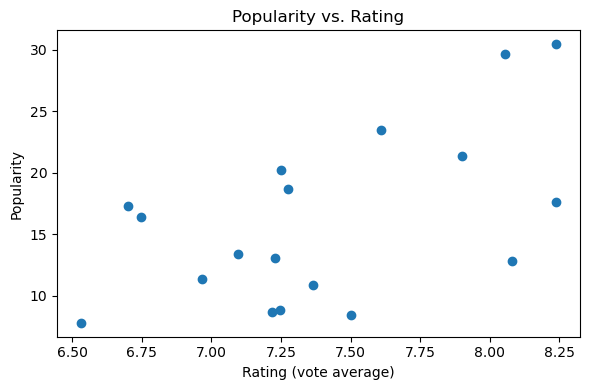

In [24]:
plt.figure(figsize=(6, 4))
plt.scatter(df["vote_average"], df["popularity"], color="#1f77b4")
plt.xlabel("Rating (vote average)")
plt.ylabel("Popularity")
plt.title("Popularity vs. Rating")
plt.grid(False)
plt.tight_layout()
plt.show()